## Name: Chandrika M jethva
## Roll no: 130
## Class / Btach: SE AIML / B - 2
## Date: 12 / 03 / 2026
## Experiment-8: Clustering of Countries with World Bank API.

In [57]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

### Part A: Dataset

In [58]:
def fetch_indicator(code, year = "2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    # {
    #     "country": {"id": "IN", "value: "India"},
    #     "value": 2400
    # }

    data = {}
    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value

    return pd.Series(data, name = code)

In [59]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [83]:
df = pd.concat([gdp, pop, life, lit], axis = 1)

# Define new column name
df.columns = ["GDP", "Population", "LifeExpectancy", "Literacy"]

# Remove missing data
df.dropna(inplace = True)

df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [84]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [85]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

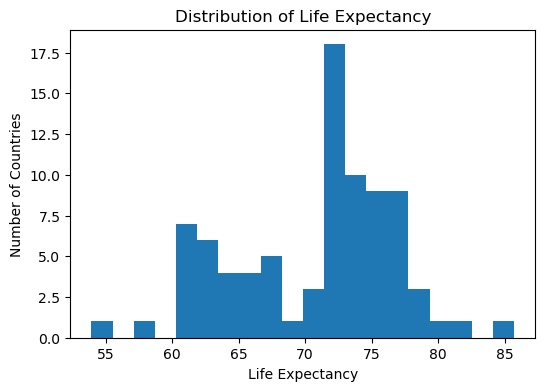

In [86]:
plt.figure(figsize = (6, 4))
plt.hist(df["LifeExpectancy"], bins = 20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of Life Expectancy")
plt.show()

### Part B: Elbow Method

In [87]:
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters = k, random_state = 0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i + 1, "\t", wcss[i])

k	WCSS
1 	 336.0
2 	 206.43717192603816
3 	 142.06028324967593
4 	 122.4640064142117
5 	 68.71234707726032
6 	 56.092718405819134
7 	 51.08265517326419
8 	 41.70851027024397
9 	 31.213863029560216
10 	 27.047250986507716


c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

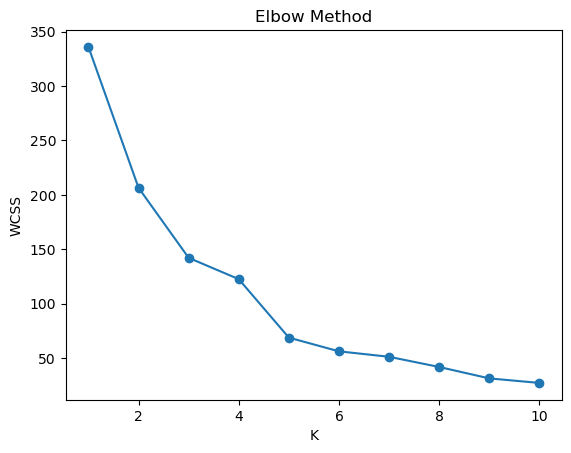

In [88]:
plt.plot(range(1, 11), wcss, marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Part C: Clustering Algorithms

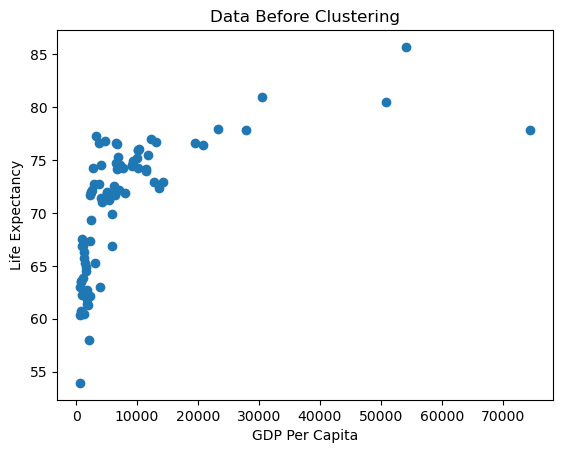

In [89]:
plt.scatter(df["GDP"], df["LifeExpectancy"])
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")
plt.show()

### 1. K-Mean Cluster

In [90]:
kmeans = KMeans(n_clusters = 3, random_state = 0)

# Label the clusters mean give numbers to them and add it as column KMean Classifier
labels_km = kmeans.fit_predict(X_scaled)

df["KMeansCluster"] = labels_km

c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


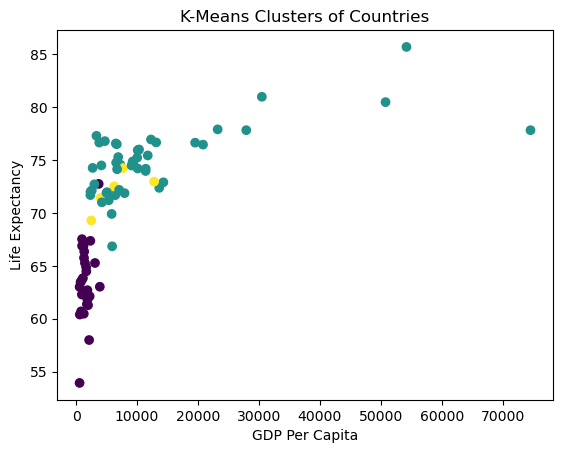

In [91]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c = labels_km)
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters of Countries")
plt.show()

In [92]:
hc = AgglomerativeClustering(n_clusters = 3)
labels_hc = hc.fit_predict(X_scaled)

df["HierarchicalCluster"] = labels_hc

### 2. Hierarchical Cluster

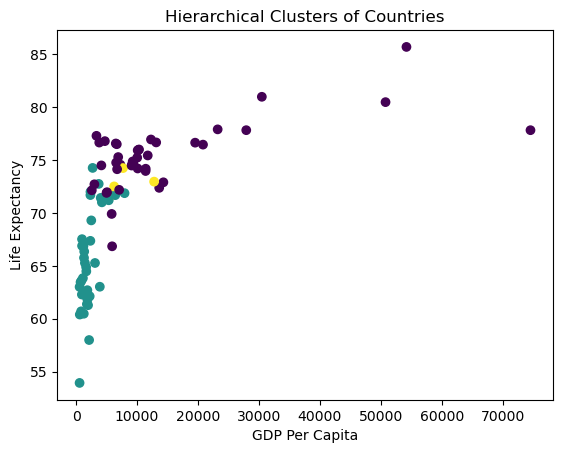

In [93]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c = labels_hc)
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Clusters of Countries")
plt.show()

In [94]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()

print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1601.971896  4.854521e+08       63.478867  66.779721
1              12288.225626  4.669122e+08       74.753258  92.910908
2               6437.349751  5.501554e+09       71.975830  84.851687


### Part D: Country Output

In [106]:
country_name = "India"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per Capita:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:",result["KMeansCluster"])
print("Hierarachical Cluster:", result["HierarchicalCluster"])

Country: India
GDP per Capita: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 1.0
Hierarachical Cluster: 1.0


In [107]:
country_name = "India"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per Capita:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:",result["KMeansCluster"])
print("Hierarachical Cluster:", result["HierarchicalCluster"])

Country: India
GDP per Capita: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 1.0
Hierarachical Cluster: 1.0


In [108]:
country_name = "North America"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per Capita:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:",result["KMeansCluster"])
print("Hierarachical Cluster:", result["HierarchicalCluster"])

Country: North America
GDP per Capita: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
KMeans Cluster: 1.0
Hierarachical Cluster: 0.0


In [109]:
country_name = "Brazil"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per Capita:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:",result["KMeansCluster"])
print("Hierarachical Cluster:", result["HierarchicalCluster"])

Country: Brazil
GDP per Capita: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
KMeans Cluster: 1.0
Hierarachical Cluster: 0.0


In [110]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per Capita:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:",result["KMeansCluster"])
print("Hierarachical Cluster:", result["HierarchicalCluster"])

Country: Viet Nam
GDP per Capita: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
KMeans Cluster: 1.0
Hierarachical Cluster: 0.0


In [111]:
country_name = "Bahrain"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per Capita:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:",result["KMeansCluster"])
print("Hierarachical Cluster:", result["HierarchicalCluster"])

Country: Bahrain
GDP per Capita: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
KMeans Cluster: 1.0
Hierarachical Cluster: 0.0
